<a href="https://colab.research.google.com/github/SrushtiSunkad630/MACHINE-LEARNING-LAB/blob/main/1BM23CS341_lab_7_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iris (1) (2).csv to iris (1) (2).csv


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset (uploaded file)
data = pd.read_csv("iris (1) (2).csv")

# Display first few rows
print(data.head())

# Features and target
X = data.iloc[:, :-1]   # all columns except last
y = data.iloc[:, -1]    # last column (species)

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- Linear Kernel ----------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("\nLinear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

cm_linear = confusion_matrix(y_test, y_pred_linear)
print("Linear Kernel Confusion Matrix:\n", cm_linear)

sns.heatmap(cm_linear, annot=True, fmt='d')
plt.title("Confusion Matrix - Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ---------------- RBF Kernel ----------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("RBF Kernel Confusion Matrix:\n", cm_rbf)

sns.heatmap(cm_rbf, annot=True, fmt='d')
plt.title("Confusion Matrix - RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'iris (1) (2).csv'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving drug.csv to drug.csv


   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY
Accuracy Score: 1.0
Confusion Matrix:
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


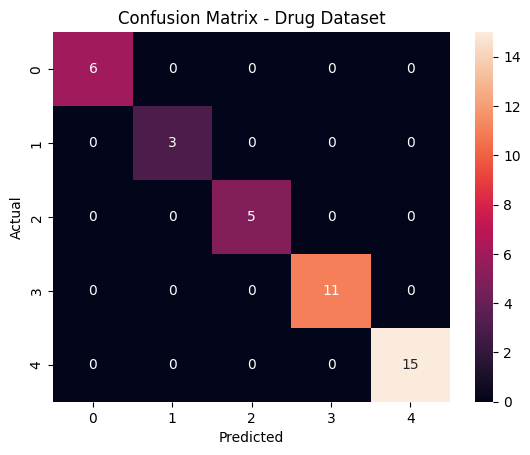

In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("drug.csv")

# Display first rows
print(data.head())

# Convert categorical data to numerical using LabelEncoder
le = LabelEncoder()

for column in data.columns:
    data[column] = le.fit_transform(data[column])

# Features and target
X = data.iloc[:, :-1]   # all columns except last
y = data.iloc[:, -1]    # drug type

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Prediction
y_pred = svm_model.predict(X_test)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Drug Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
data = pd.read_csv("letter-recognition.csv")

# Features and target
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM classifier
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()


# -------- ROC Curve --------

classes = sorted(y.unique())

y_test_bin = label_binarize(y_test, classes=classes)
y_train_bin = label_binarize(y_train, classes=classes)

classifier = OneVsRestClassifier(SVC(kernel='linear', probability=True))
y_score = classifier.fit(X_train, y_train_bin).decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving letter-recognition.csv to letter-recognition.csv


Accuracy: 0.8545
Confusion Matrix:
 [[140   1   0   0   0   0   2   0   0   2   0   0   0   0   0   0   0   1
    1   0   0   1   0   0   1   0]
 [  1 133   0   3   0   0   0   5   0   0   1   0   0   1   0   1   0   6
    1   0   0   1   0   0   0   0]
 [  0   0 117   0   1   0   4   2   0   0   6   1   0   0   3   0   0   0
    1   0   2   0   0   0   0   0]
 [  0   6   0 141   0   0   0   2   0   1   2   0   0   1   1   0   0   0
    0   2   0   0   0   0   0   0]
 [  0   1   2   0 127   0   4   0   0   0   1   1   0   0   0   0   1   1
    2   1   0   0   0   0   0   0]
 [  0   0   0   0   3 127   0   1   2   1   0   0   0   0   0   1   0   0
    2   3   0   0   0   0   0   0]
 [  0   1   8   2   0   0 129   2   0   1   3   0   0   0   0   0   7   1
    2   0   0   2   2   0   0   0]
 [  1   4   1  10   1   2   0  85   0   3   6   0   0   2  10   1   2  12
    0   0   2   0   0   1   1   0]
 [  0   0   0   3   0   2   0   0 127   6   0   2   0   0   0   0   1   0
    1   0   0   0 

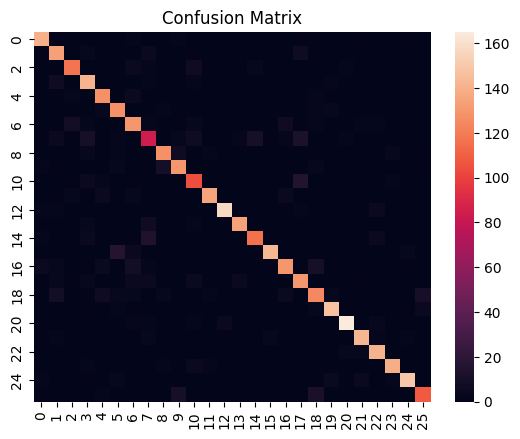

AUC Score: 0.9240836687467961


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

# Load dataset
data = pd.read_csv("letter-recognition.csv")

# Features and target
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM (faster kernel)
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

# ROC + AUC
y_test_bin = label_binarize(y_test, classes=list(range(26)))
y_pred_bin = label_binarize(y_pred, classes=list(range(26)))

auc_score = roc_auc_score(y_test_bin, y_pred_bin, average="macro")

print("AUC Score:", auc_score)